# Visualisasi Output Transfer Learning

Notebook ini membaca hasil dari `outputs/transfer_learning/` dan menampilkan ringkasan dalam bentuk tabel dan grafik.

In [3]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

OUTPUT_DIR = Path('../outputs/transfer_learning')
assert OUTPUT_DIR.exists(), f'Output directory tidak ditemukan: {OUTPUT_DIR.resolve()}'

plt.style.use('default')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 120)

## File Output yang Tersedia

In [4]:
files = []
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        files.append({
            'file': str(path.relative_to(OUTPUT_DIR)),
            'size_kb': round(path.stat().st_size / 1024, 2),
        })
pd.DataFrame(files)

,file,size_kb
0,best_model_stage_a.pth,27794.04
1,best_model_stage_b.pth,27794.04
2,class_distribution.csv,0.29
3,class_distribution.json,1.01
4,config_used.yaml,0.66
5,final_model.pth,27789.42
6,gradcam\0000_CXR075_001_infiltrat.jpg,4.71
7,gradcam\0001_CXR075_002_infiltrat.jpg,4.78
8,gradcam\0002_CXR072_001_infiltrat.jpg,6.20
9,gradcam\0003_CXR070_001_infiltrat.jpg,5.71


## Ringkasan Metrik Test dan Validation

In [5]:
def load_json(name):
    path = OUTPUT_DIR / name
    if not path.exists():
        return None
    return json.loads(path.read_text(encoding='utf-8'))

test_metrics = load_json('test_metrics.json')
validation_metrics = load_json('validation_metrics.json')

summary_keys = [
    'exact_match_accuracy',
    'micro_precision',
    'micro_recall',
    'micro_f1',
    'macro_precision',
    'macro_recall',
    'macro_f1',
]

rows = []
for key in summary_keys:
    rows.append({
        'metric': key,
        'validation': None if validation_metrics is None else validation_metrics.get(key),
        'test': None if test_metrics is None else test_metrics.get(key),
    })

summary_df = pd.DataFrame(rows)
summary_df

,metric,validation,test
0,exact_match_accuracy,0.177778,0.100000
1,micro_precision,0.460870,0.444444
2,micro_recall,0.883333,0.666667
3,micro_f1,0.605714,0.533333
4,macro_precision,0.362784,0.281250
5,macro_recall,0.483080,0.212500
6,macro_f1,0.403500,0.208333


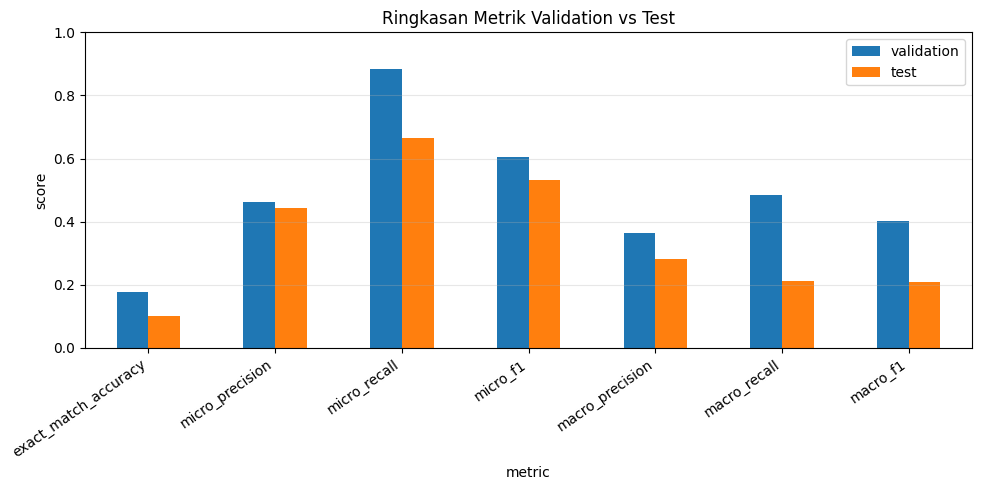

In [6]:
if not summary_df.empty:
    ax = summary_df.set_index('metric')[['validation', 'test']].plot(kind='bar', figsize=(10, 5))
    ax.set_title('Ringkasan Metrik Validation vs Test')
    ax.set_ylabel('score')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

## Metrik Per Kelas

In [7]:
def per_class_df(metrics, split_name):
    if not metrics or 'per_class' not in metrics:
        return pd.DataFrame()
    rows = []
    for class_name, values in metrics['per_class'].items():
        row = {'split': split_name, 'class_name': class_name}
        row.update(values)
        rows.append(row)
    return pd.DataFrame(rows)

per_class = pd.concat(
    [per_class_df(validation_metrics, 'validation'), per_class_df(test_metrics, 'test')],
    ignore_index=True,
)
per_class

,split,class_name,precision,recall,f1,roc_auc,pr_auc
0,validation,kavitas,0.800000,0.666667,0.727273,None,None
1,validation,infiltrat,0.818182,0.972973,0.888889,None,None
2,validation,limfadenopati,0.000000,0.000000,0.000000,None,None
3,validation,tuberkuloma,0.000000,0.000000,0.000000,None,None
4,validation,bronkiektasis,0.000000,0.000000,0.000000,None,None
5,validation,pneumothorax,0.272727,0.600000,0.375000,None,None
6,validation,efusi pleura,0.375000,0.750000,0.500000,None,None
7,validation,atelektasis,0.636364,0.875000,0.736842,None,None
8,test,kavitas,1.000000,0.200000,0.333333,None,None
9,test,infiltrat,1.000000,1.000000,1.000000,None,None


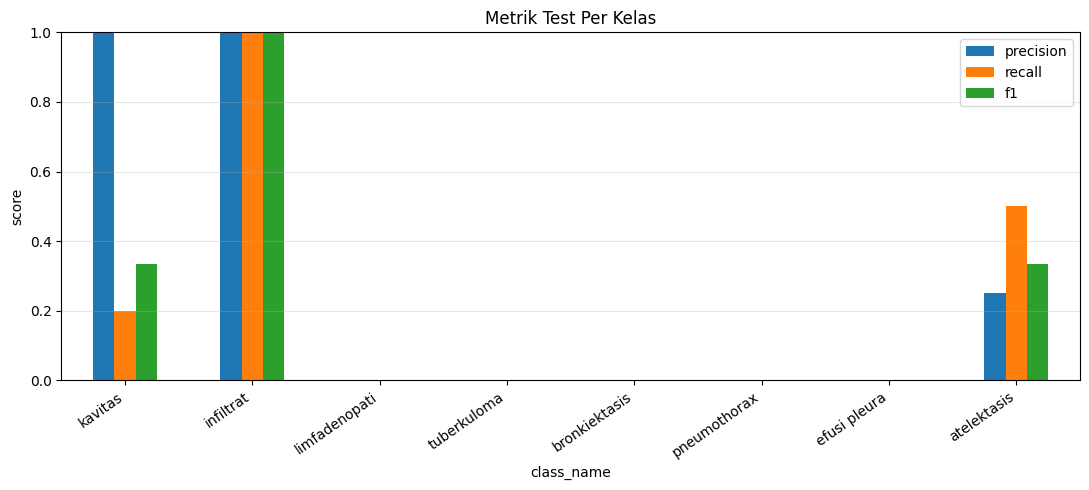

In [8]:
if not per_class.empty:
    test_per_class = per_class[per_class['split'] == 'test'].set_index('class_name')
    ax = test_per_class[['precision', 'recall', 'f1']].plot(kind='bar', figsize=(11, 5))
    ax.set_title('Metrik Test Per Kelas')
    ax.set_ylabel('score')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

## Threshold Hasil Validation Tuning

In [9]:
thresholds = load_json('thresholds.json') or {}
threshold_df = pd.DataFrame([
    {
        'class_name': class_name,
        'threshold': values.get('threshold') if isinstance(values, dict) else values,
        'validation_f1': values.get('validation_f1') if isinstance(values, dict) else None,
    }
    for class_name, values in thresholds.items()
])
threshold_df

,class_name,threshold,validation_f1
0,kavitas,0.70,0.727273
1,infiltrat,0.10,0.888889
2,limfadenopati,0.10,0.000000
3,tuberkuloma,0.10,0.000000
4,bronkiektasis,0.10,0.000000
5,pneumothorax,0.25,0.375000
6,efusi pleura,0.80,0.500000
7,atelektasis,0.55,0.736842


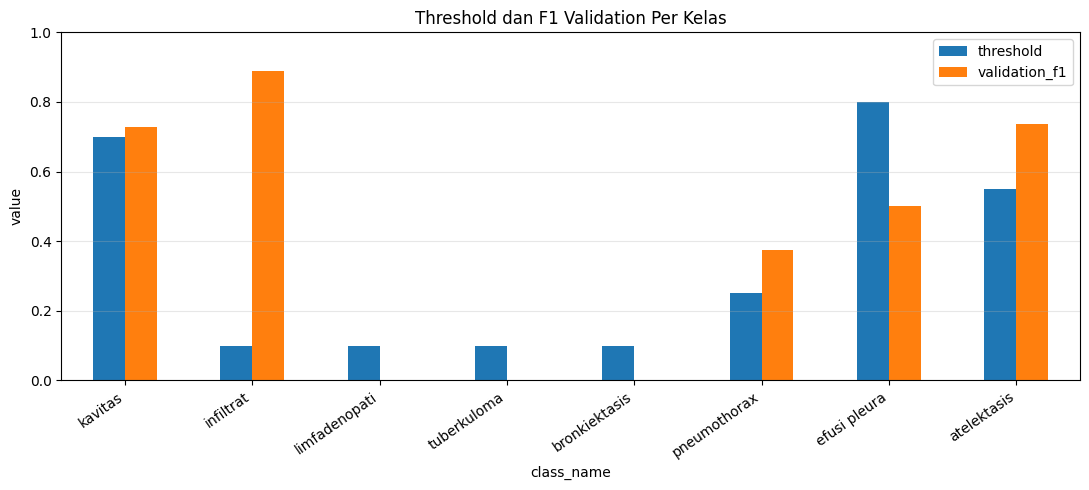

In [10]:
if not threshold_df.empty:
    ax = threshold_df.set_index('class_name')[['threshold', 'validation_f1']].plot(kind='bar', figsize=(11, 5))
    ax.set_title('Threshold dan F1 Validation Per Kelas')
    ax.set_ylabel('value')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

## Distribusi Kelas Training

In [11]:
class_distribution_path = OUTPUT_DIR / 'class_distribution.csv'
class_distribution = pd.read_csv(class_distribution_path) if class_distribution_path.exists() else pd.DataFrame()
class_distribution

,class_name,positive_count,negative_count,pos_weight
0,kavitas,42,118,2.809524
1,infiltrat,135,25,0.185185
2,limfadenopati,0,160,160.000000
3,tuberkuloma,4,156,39.000000
4,bronkiektasis,0,160,160.000000
5,pneumothorax,1,159,159.000000
6,efusi pleura,18,142,7.888889
7,atelektasis,8,152,19.000000


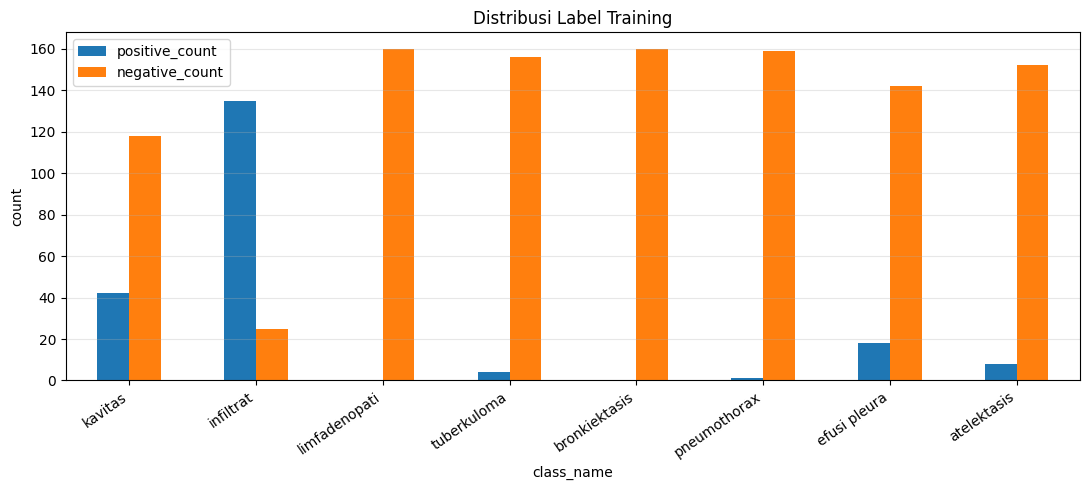

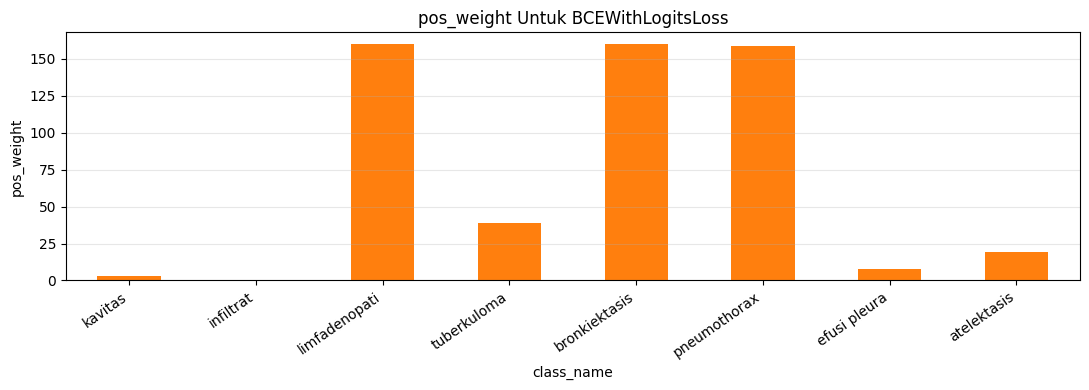

In [12]:
if not class_distribution.empty:
    ax = class_distribution.set_index('class_name')[['positive_count', 'negative_count']].plot(kind='bar', figsize=(11, 5))
    ax.set_title('Distribusi Label Training')
    ax.set_ylabel('count')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

    ax = class_distribution.set_index('class_name')['pos_weight'].plot(kind='bar', figsize=(11, 4), color='tab:orange')
    ax.set_title('pos_weight Untuk BCEWithLogitsLoss')
    ax.set_ylabel('pos_weight')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

## Training Log Stage A dan Stage B

In [13]:
training_log_path = OUTPUT_DIR / 'training_log.csv'
training_log = pd.read_csv(training_log_path) if training_log_path.exists() else pd.DataFrame()
training_log

,stage,epoch,train_loss,val_loss
0,A,1,1.231462,6.667536
1,A,2,0.978296,4.477697
2,A,3,0.769523,3.370406
3,A,4,0.738183,2.845776
4,A,5,0.617289,2.916109
5,A,6,0.633411,3.018411
6,A,7,0.564780,2.599975
7,A,8,0.504855,3.092397
8,A,9,0.517610,3.583993
9,A,10,0.487466,3.347793


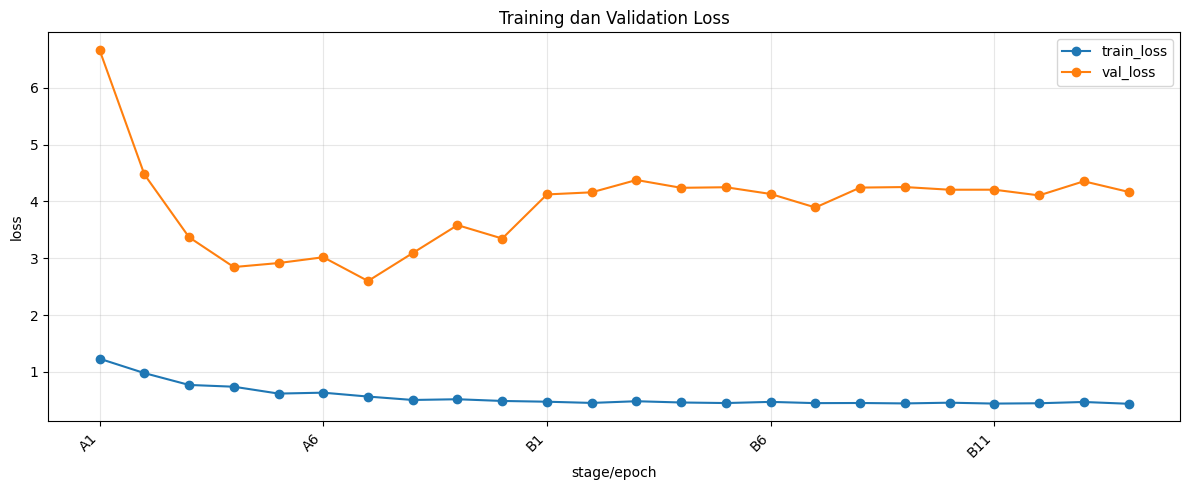

,stage,epoch,train_loss,val_loss
0,A,7,0.564780,2.599975
1,B,7,0.449184,3.894440


In [14]:
if not training_log.empty:
    plot_df = training_log.copy()
    plot_df['epoch_label'] = plot_df['stage'].astype(str) + plot_df['epoch'].astype(str)
    ax = plot_df.plot(x='epoch_label', y=['train_loss', 'val_loss'], marker='o', figsize=(12, 5))
    ax.set_title('Training dan Validation Loss')
    ax.set_xlabel('stage/epoch')
    ax.set_ylabel('loss')
    ax.grid(alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    best_rows = training_log.loc[training_log.groupby('stage')['val_loss'].idxmin()].reset_index(drop=True)
    display(best_rows)

## Prediksi Test

In [15]:
predictions_path = OUTPUT_DIR / 'test_predictions.csv'
predictions = pd.read_csv(predictions_path) if predictions_path.exists() else pd.DataFrame()
predictions.head(20)

,filename,path,ground_truth_labels,predicted_labels,prob_kavitas,pred_kavitas,true_kavitas,prob_infiltrat,pred_infiltrat,true_infiltrat,prob_limfadenopati,pred_limfadenopati,true_limfadenopati,prob_tuberkuloma,pred_tuberkuloma,true_tuberkuloma,prob_bronkiektasis,pred_bronkiektasis,true_bronkiektasis,prob_pneumothorax,pred_pneumothorax,true_pneumothorax,prob_efusi_pleura,pred_efusi_pleura,true_efusi_pleura,prob_atelektasis,pred_atelektasis,true_atelektasis
0,CXR075_001.jpg,Splitted dataset\Splitted dataset\test\atelektasis\CXR075_001.jpg,kavitas|infiltrat|atelektasis,infiltrat|tuberkuloma|efusi pleura|atelektasis,0.324756,0,1,0.626721,1,1,6.681081e-04,0,0,0.352183,1,0,0.001116,0,0,0.241507,0,0,0.837192,1,0,0.574742,1,1
1,CXR075_002.jpg,Splitted dataset\Splitted dataset\test\atelektasis\CXR075_002.jpg,kavitas|infiltrat|atelektasis,infiltrat|tuberkuloma,0.394076,0,1,0.622730,1,1,7.444261e-04,0,0,0.215350,1,0,0.001335,0,0,0.118577,0,0,0.783737,0,0,0.534838,0,1
2,CXR072_001.jpg,Splitted dataset\Splitted dataset\test\efusi pleura\CXR072_001.jpg,kavitas|infiltrat|efusi pleura,infiltrat|tuberkuloma|pneumothorax|atelektasis,0.638859,0,1,0.744196,1,1,2.029915e-03,0,0,0.544687,1,0,0.001997,0,0,0.362606,1,0,0.417523,0,1,0.789811,1,0
3,CXR070_001.jpg,Splitted dataset\Splitted dataset\test\infiltrat\CXR070_001.jpg,kavitas|infiltrat,infiltrat|tuberkuloma,0.677207,0,1,0.786480,1,1,2.147397e-04,0,0,0.613965,1,0,0.000322,0,0,0.248244,0,0,0.502732,0,0,0.245466,0,0
4,CXR070_002.jpg,Splitted dataset\Splitted dataset\test\infiltrat\CXR070_002.jpg,infiltrat,infiltrat|tuberkuloma|pneumothorax,0.432977,0,0,0.514374,1,1,6.772568e-05,0,0,0.593416,1,0,0.000135,0,0,0.347657,1,0,0.675909,0,0,0.509150,0,0
5,CXR070_003.jpg,Splitted dataset\Splitted dataset\test\infiltrat\CXR070_003.jpg,infiltrat,infiltrat|tuberkuloma,0.539118,0,0,0.711057,1,1,3.642494e-04,0,0,0.626814,1,0,0.000661,0,0,0.246549,0,0,0.572980,0,0,0.316512,0,0
6,CXR071_001.jpg,Splitted dataset\Splitted dataset\test\infiltrat\CXR071_001.jpg,infiltrat,infiltrat,0.185121,0,0,0.322778,1,1,5.083903e-07,0,0,0.046804,0,0,0.000001,0,0,0.014419,0,0,0.293424,0,0,0.047648,0,0
7,CXR073_001.jpg,Splitted dataset\Splitted dataset\test\infiltrat\CXR073_001.jpg,kavitas|infiltrat,kavitas|infiltrat|tuberkuloma|atelektasis,0.821489,1,1,0.912186,1,1,2.019696e-04,0,0,0.366261,1,0,0.000187,0,0,0.116348,0,0,0.137810,0,0,0.618235,1,0
8,CXR073_002.jpg,Splitted dataset\Splitted dataset\test\infiltrat\CXR073_002.jpg,infiltrat,infiltrat|tuberkuloma|atelektasis,0.697752,0,0,0.813181,1,1,2.399988e-04,0,0,0.203420,1,0,0.000235,0,0,0.085525,0,0,0.403570,0,0,0.608515,1,0
9,CXR073_003.jpg,Splitted dataset\Splitted dataset\test\infiltrat\CXR073_003.jpg,infiltrat,infiltrat|tuberkuloma,0.364012,0,0,0.635832,1,1,1.107449e-05,0,0,0.330122,1,0,0.000021,0,0,0.105460,0,0,0.588571,0,0,0.391157,0,0


,class_name,true_count,predicted_count
0,atelektasis,2,4
1,efusi pleura,1,1
2,infiltrat,10,10
3,kavitas,5,1
4,pneumothorax,0,2
5,tuberkuloma,0,9


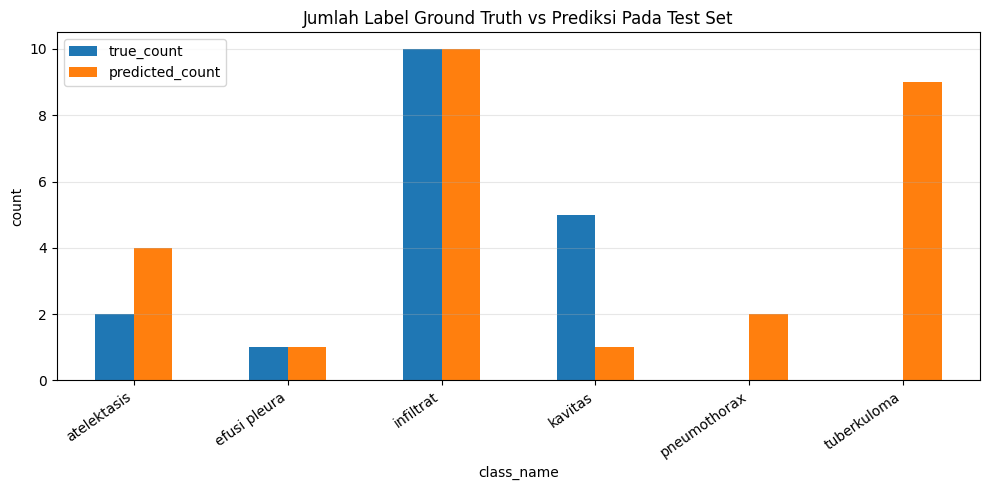

In [16]:
if not predictions.empty:
    pred_label_counts = predictions['predicted_labels'].fillna('').str.split('|').explode()
    pred_label_counts = pred_label_counts[pred_label_counts != ''].value_counts().rename_axis('class_name').reset_index(name='predicted_count')

    true_label_counts = predictions['ground_truth_labels'].fillna('').str.split('|').explode()
    true_label_counts = true_label_counts[true_label_counts != ''].value_counts().rename_axis('class_name').reset_index(name='true_count')

    label_counts = pd.merge(true_label_counts, pred_label_counts, on='class_name', how='outer').fillna(0)
    label_counts[['true_count', 'predicted_count']] = label_counts[['true_count', 'predicted_count']].astype(int)
    display(label_counts)

    ax = label_counts.set_index('class_name')[['true_count', 'predicted_count']].plot(kind='bar', figsize=(10, 5))
    ax.set_title('Jumlah Label Ground Truth vs Prediksi Pada Test Set')
    ax.set_ylabel('count')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

## Grad-CAM Output

In [17]:
gradcam_dir = OUTPUT_DIR / 'gradcam'
gradcam_index_path = gradcam_dir / 'gradcam_index.csv'
gradcam_index = pd.read_csv(gradcam_index_path) if gradcam_index_path.exists() else pd.DataFrame()
gradcam_index.head(20)

,output_file,filename,predicted_class,probability,ground_truth_labels
0,0000_CXR075_001_infiltrat.jpg,CXR075_001.jpg,infiltrat,0.626640,kavitas|infiltrat|atelektasis
1,0001_CXR075_002_infiltrat.jpg,CXR075_002.jpg,infiltrat,0.622869,kavitas|infiltrat|atelektasis
2,0002_CXR072_001_infiltrat.jpg,CXR072_001.jpg,infiltrat,0.744185,kavitas|infiltrat|efusi pleura
3,0003_CXR070_001_infiltrat.jpg,CXR070_001.jpg,infiltrat,0.786418,kavitas|infiltrat
4,0004_CXR070_002_infiltrat.jpg,CXR070_002.jpg,infiltrat,0.514224,infiltrat
5,0005_CXR070_003_infiltrat.jpg,CXR070_003.jpg,infiltrat,0.711132,infiltrat
6,0006_CXR071_001_infiltrat.jpg,CXR071_001.jpg,infiltrat,0.323058,infiltrat
7,0007_CXR073_001_kavitas.jpg,CXR073_001.jpg,kavitas,0.821438,kavitas|infiltrat
8,0008_CXR073_002_infiltrat.jpg,CXR073_002.jpg,infiltrat,0.813269,infiltrat
9,0009_CXR073_003_infiltrat.jpg,CXR073_003.jpg,infiltrat,0.635843,infiltrat


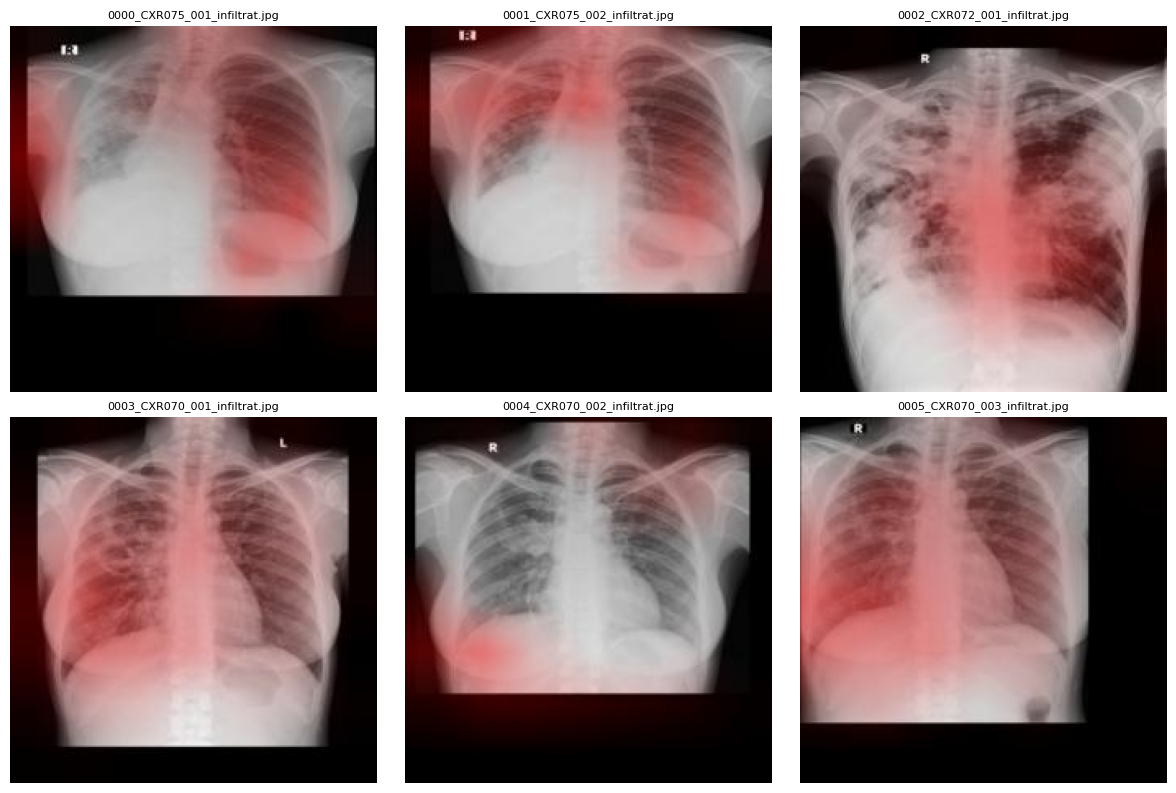

In [18]:
from PIL import Image

image_files = sorted([p for p in gradcam_dir.glob('*.jpg')]) if gradcam_dir.exists() else []
image_files = image_files[:6]

if image_files:
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    for ax, image_path in zip(axes, image_files):
        ax.imshow(Image.open(image_path))
        ax.set_title(image_path.name, fontsize=8)
        ax.axis('off')
    for ax in axes[len(image_files):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Belum ada file Grad-CAM .jpg di', gradcam_dir)